| Technological Institute of the Philippines | Quezon City - Computer Engineering |
|-------------------------------------------|------------------------------------|
| **Course Code:** | CPE 018 |
| **Code Title:** | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision |
| **1st Semester** | AY 2025-2026 |
| **ACTIVITY NO. 5** | **Line and Circle Detection** |
| **Name:** | Pascual, Ken Leonard |
| **Section:** | CPE31S3 |
| **Date Performed:** | 23 September 2025 |
| **Date Submitted:** | 23 September 2025 |
| **Instructor:** | Engr. Verlyn V. Nojor |


## 1. Objectives

This activity aims to introduce students to openCV's APIs for Hough Transform.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize openCV for circle and line detection.
* Analyze the use of hough Line and Circle function for finding objects in an image.

## 3. Procedures and Outputs

Detecting edges and contours are not only common and important tasks, they also constitute the basis for other complex operations. Lines and shape detection go hand in hand with edge and contour detection, so let's examine how OpenCV implements these.

### Line Detection

The theory behind lines and shape detection has its foundation in a technique called the Hough transform, invented by Richard Duda and Peter Hart, who extended (generalized) the work done by Paul Hough in the early 1960s.

Let's take a look at OpenCV's API for the Hough transforms.

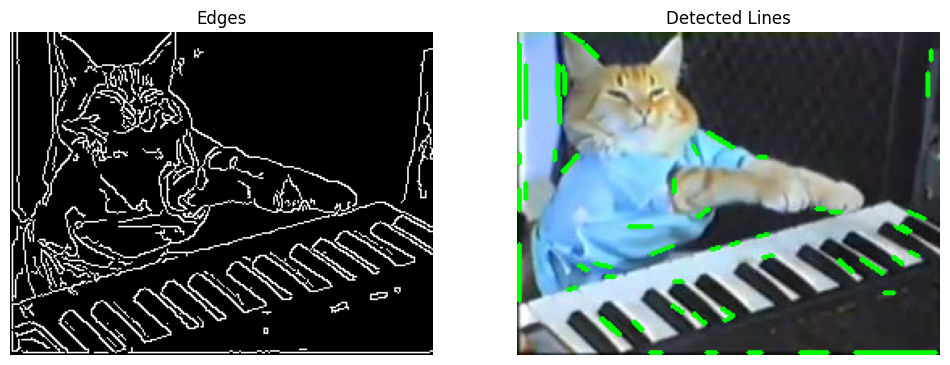

In [86]:
# Image source: https://en.wikipedia.org/wiki/Keyboard_Cat
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('Keyboard_cat.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 120)

# Line detection
minLineLength =  1
maxLineGap = 5
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 0,
                        minLineLength, maxLineGap)

# Draw lines if found
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show results
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Edges")
plt.imshow(edges, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Detected Lines")
plt.imshow(img_rgb)
plt.axis('off')

plt.show()


The crucial point of this simple script —aside from the HoughLines function call— is the setting of minimum line length (shorter lines will be discarded) and the maximum line gap, which is the maximum size of a gap in a line before the two segments start being considered as separate lines.

Also note that the HoughLines function takes a single channel binary image, processed through the Canny edge detection filter. Canny is not a strict requirement, however; an image that's been denoised and only represents edges, is the ideal source for a Hough transform, so you will find this to be a common practice.

The parameters of HoughLinesP are as follows:
- The image we want to process.
- The geometrical representations of the lines, rho and theta, which are usually 1 and np.pi/180.
- The threshold, which represents the threshold below which a line is discarded. The Hough transform works with a system of bins and votes, with each bin representing a line, so any line with a minimum of the <threshold> votes is retained, the rest discarded.
- MinLineLength and MaxLineGap, which we mentioned previously

**Questions:**

1. Which line of code is responsible for setting the minimum line length?

In [ ]:
minLineLength =  8

2. What is the mathematical formula for Hough transform and explain how it finds lines.

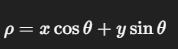

*The Hough transform uses the polar representation of a line, where the result (ρ) is the perpendicular distance from tthe origin to the line, and θ represents the angle of the perpendicular line with respect to the x-axis, while x and y represent the coordinates of a point in the image.*

*The idea behind the Hough transform is that it converts the problem of detecting collinear pixels (a line in image space) into detecting intersections in parameter space. Lines are then reconstructed from these parameters.*

### Circle Detection

OpenCV also has a function for detecting circles, called HoughCircles. It works in a very similar fashion to HoughLines, but where minLineLength and maxLineGap were the parameters to discard or retain lines, HoughCircles has a minimum distance between circles' centers, minimum, and maximum radius of the circles. Here's the obligatory example:

Before going into the sample code, check first: **What is the HoughCircles function and what are its parameters?**

In [ ]:
circles = cv2.HoughCircles(image, method, dp, minDist,
                           param1=100, param2=30,
                           minRadius=0, maxRadius=0)

**Parameters:**
* ***image*** - input grayscale image
* ***method*** - cv2.HOUGH_GRADIENT, which uses edge detection + center voting
* ***dp*** - scaling factor between the input image resolution and the accumulator resolution
* ***minDist*** - minimum distance between circle centers
* ***param1*** - higher threshold for Canny edge detection
* ***param2*** - accumulator threshold for Canny edge detection
* ***minRadius*** - minimum circle radius
* ***maxRadius*** - filters out circles larger than this value

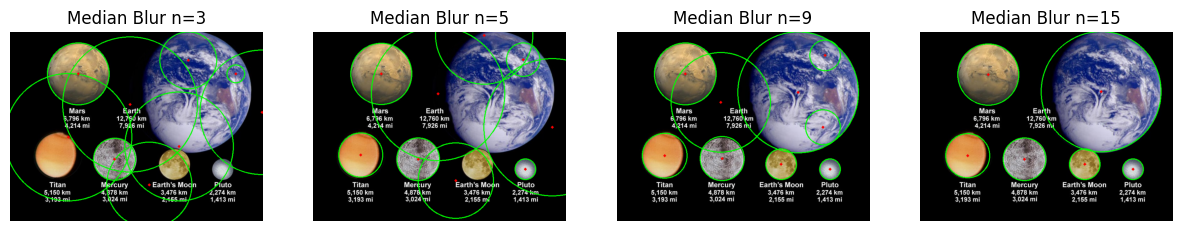

In [96]:
#image reference: https://www.elephango.com/index.cfm/pg/k12learning/lcid/11754
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Values of n to test
n_values = [3, 5, 9, 15]

#Load image
planets = cv2.imread('planets.jpg')

plt.figure(figsize=(15,5))

for idx, n in enumerate(n_values, 1):
    gray_img = cv2.cvtColor(planets, cv2.COLOR_BGR2GRAY)
    img = cv2.medianBlur(gray_img, n)

    #Detect circles
    circles = cv2.HoughCircles(img, cv2.HOUGH_GRADIENT, 1, 120,
                               param1=100, param2=30, minRadius=10, maxRadius=300)

    output = planets.copy()

    if circles is not None:
        circles = np.around(circles).astype(int)
        cleaned = []
        for (x, y, r) in circles[0, :]:
            #Skip unreasonable circles
            if r < 15 or r > 200:
                continue

            #Brightness check
            mask = np.zeros_like(gray_img)
            cv2.circle(mask, (x, y), r, 255, -1)
            mean_val = cv2.mean(gray_img, mask=mask)[0]
            if mean_val < 30:  
                continue

            cleaned.append((x, y, r))

        #Deduplicate circles: keep largest per cluster
        final = []
        for (x, y, r) in sorted(cleaned, key=lambda c: -c[2]):  # sort by radius desc
            if all(np.hypot(x - fx, y - fy) > (r + fr) * 0.5 for (fx, fy, fr) in final):
                final.append((x, y, r))

        #Draw final circles
        for (x, y, r) in final:
            cv2.circle(output, (x, y), r, (0, 255, 0), 2)
            cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

    output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 4, idx)
    plt.title(f"Median Blur n={n}")
    plt.imshow(output_rgb)
    plt.axis("off")

plt.show()

What happens to the code once you run **and the value of n is 5**?

*When the value of n is 5, the circles outlined by HoughCircles are all over the place, as it also detects circles due to noise in the image.*

Change the value to 9, **what happens to the image**?

*When the value of n is 9, the circles outlined by HoughCircles are a bit all over the place, as it also detects circles due to noise in the image.*

Lastly, change the value to 15, **what can you say about the resulting image?**

*When the value of n is 5, the circles outlined by HoughCircles perfectly outlines the planets, nothing else.*

Provide an analysis of the output so far. How does the code help the changes in the resulting image?

*It seems that the value of n signifies the kernel size used to apply median blur, which affects how much the image is smoothed before running HoughCircles. As n increases, the amount of noise in the image decreases. Allowing for detection of bigger circles. While a smaller amount of median blur is great for detecting smaller circles, the amount of noise also makes it so HoughCircles also detects circles that aren't supposed to be there. A bigger amount however, may make HoughCircles ignore the smaller circles, so it's all about balance when it comes to adjusting the value.*

## 4. Supplementary Activity

The attached image contains coins used in the Philippines.

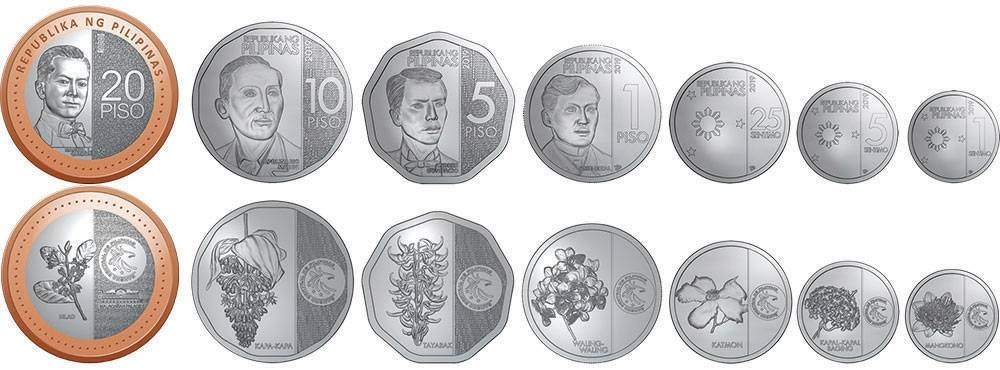

Your job is to count the amount of coins (denomation not included, no sum of prices; just the amount of coins present) through either line detection or circle detection.

- Create a function using line detection and pass this image as parameter, what is the output? Can you use houghlines to count circles?

*As seen from the output of the code below, HoughLines cannot be used to count circles in this scenario. Since it detects all lines within the image, and coins consist of a lot of lines in their patterns, HoughLines cannot be used to detect how many coins there are in a given image. However, it can count how many lines are in each coin.*

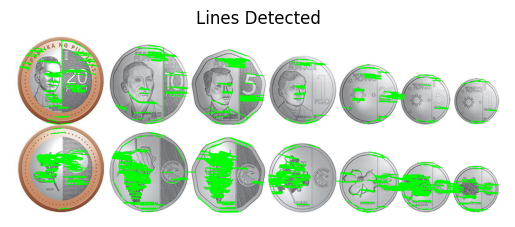

Line count (not coins): 891


In [131]:
#image reference: https://www.gmanetwork.com/news/money/economy/837202/no-new-coin-series-released-says-bsp/story/
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = 'coins.jpg'
def count_coins_with_lines(image_path):
    #Load and preprocess
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 200, 300)

    #Line detection
    lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=100,
                            minLineLength=30, maxLineGap=10)

    output = img.copy()
    line_count = 0

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)
            line_count += 1

    #Show result
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Lines Detected")
    plt.show()

    return line_count

lines_found = count_coins_with_lines("coins.jpg")
print("Line count (not coins):", lines_found)


- Create a function using circle detection and pass this image as parameter, show the output? Can you use houghcircles to count the circles?

*Since the problem in hand involves circle detection, HoughCircles is best applicable in this scenario. As seen from the output below, given the correct values in its parameters, HoughCircles can detect circles accurately to count the number of coins in the image. All it takes is the right amount of blur and a few tweaks in param2 and maxRadius to get the desired result.*

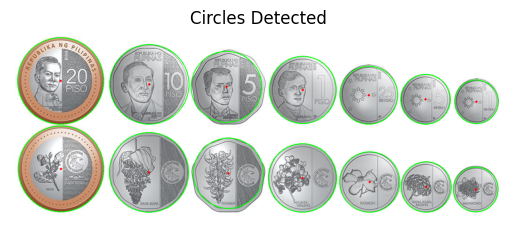

Coin count: 14


In [180]:
#image reference: https://www.gmanetwork.com/news/money/economy/837202/no-new-coin-series-released-says-bsp/story/
import cv2
import numpy as np
import matplotlib.pyplot as plt

def count_coins_with_circles(image_path):
    #Load and preprocess
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 31)

    #Circle detection
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1.2, minDist=30,
                               param1=100, param2=45, minRadius=20, maxRadius=140)

    output = img.copy()
    coin_count = 0

    if circles is not None:
        circles = np.around(circles).astype(int)
        coin_count = len(circles[0])
        for (x, y, r) in circles[0, :]:
            cv2.circle(output, (x, y), r, (0, 255, 0), 2)
            cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

    #Show result
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Circles Detected")
    plt.show()

    return coin_count

coins_found = count_coins_with_circles("coins.jpg")
print("Coin count:", coins_found)


## 5. Summary, Conclusions and Lessons Learned

*In this activity, I was able to learn about line and circle detection using HoughLines and HoughCircles. One thing that's important in doing line and circle detection is proper preprocessing of the image, which includes reducing noise in the image. With the tasks given in this activity, I was able to learn about how object detection works through HoughLines and HoughCircles. These object detection tools represent each line as polar coordinates instead of the slope-intercept form or by using the parameter space that includes the circle center and radius. This means that a point in the image space maps to a curve in parameter space. Object detection then works by finding peaks in the parameter accumulator space, or by accumulating evidence of possible circle parameters.*

*Both HoughLines and HoughCircles have their own use cases. HoughLines are best used for detecting line edges, while HoughCircles are best used for detecting circular edges.*

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*